# Deliverable 6: Single-Cell RNA-Seq Analysis

This notebook prepares the environment and data for a simplified scRNA-seq pipeline following Single-cell Best Practices. It will:
- Build a cell-gene expression matrix (AnnData)
- Cluster cells with Leiden
- Annotate cell types with CellTypist

## Important: Python 3.12 Required

**This deliverable requires Python 3.12**  
The primary reason is that `pyroe` (used for loading alevin-fry quantification data) does not work with Python 3.13 despite various attempts to resolve compatibility issues. Additionally, the `anndata` ecosystem has numpy/pandas binary compatibility constraints with Python 3.13.

### Setting up Python 3.12 Environment

I suspect you are likely using Python 3.13 in your environment. However, to run this notebook, you will need to create a separate Python 3.12 virtual environment:

```bash
# Install Python 3.12 if not already installed (Ubuntu/Debian)
sudo apt update
sudo apt install python3.12 python3.12-venv python3.12-dev

# Create a new virtual environment with Python 3.12
python3.12 -m venv .venv312

# Activate the environment
source .venv312/bin/activate

# Verify Python version
python --version  # Should show Python 3.12.x

# Start Jupyter from this environment
jupyter notebook
```

**Note**: Keep your Python 3.13 environment (`.venv` or `.venv313`) intact for previous deliverables. Use `.venv312` only for Week 6.

## System Requirements Check

This section checks and installs required Python packages:
- `scanpy`, `anndata<0.11`, `leidenalg`, `celltypist`, `matplotlib`, `pyroe`

In [69]:
import subprocess, sys, importlib

print("=== Python Environment Setup ===")
print(f"Python version: {sys.version}")

# Upgrade pip tooling
subprocess.run([sys.executable, '-m', 'pip', 'install', '--upgrade', 'pip', 'setuptools', 'wheel'], 
               stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

# Package versions (Python 3.12 compatibility)
packages = {
    'numpy': '1.26.4',
    'pandas': '2.2.2',
    'anndata': '0.10.9',
    'scanpy': '1.9.8',
    'leidenalg': None,
    'celltypist': None,
    'matplotlib': '3.9.2',
    'pyroe': None
}

def get_version(pkg):
    try:
        importlib.import_module(pkg)
        from importlib.metadata import version
        return version(pkg)
    except:
        return None

def install(pkg, ver=None):
    spec = f"{pkg}=={ver}" if ver else pkg
    result = subprocess.run([sys.executable, '-m', 'pip', 'install', '--no-cache-dir', spec],
                          capture_output=True, text=True)
    return result.returncode == 0

print("\nInstalling packages...")
for pkg, ver in packages.items():
    current = get_version(pkg)
    if current and (not ver or current == ver):
        print(f"  {pkg:15} {current} [OK]")
    else:
        print(f"  {pkg:15} Installing...", end=' ')
        if install(pkg, ver):
            print(f"{get_version(pkg)} [OK]")
        else:
            print("[FAILED]")

print("\n[READY] Environment configured. Proceed to next cell.")

=== Python Environment Setup ===
Python version: 3.12.3 (main, Aug 14 2025, 17:47:21) [GCC 13.3.0]

Installing packages...
  numpy           1.26.4 [OK]
  pandas          2.2.2 [OK]
  anndata         0.10.9 [OK]
  scanpy          1.9.8 [OK]
  leidenalg       0.11.0 [OK]
  celltypist      1.7.1 [OK]
  matplotlib      3.9.2 [OK]
  pyroe           0.9.3 [OK]

[READY] Environment configured. Proceed to next cell.

Installing packages...
  numpy           1.26.4 [OK]
  pandas          2.2.2 [OK]
  anndata         0.10.9 [OK]
  scanpy          1.9.8 [OK]
  leidenalg       0.11.0 [OK]
  celltypist      1.7.1 [OK]
  matplotlib      3.9.2 [OK]
  pyroe           0.9.3 [OK]

[READY] Environment configured. Proceed to next cell.


## Data Download & Setup


In [70]:
%%bash
set -e

DATA_DIR="data"
mkdir -p "$DATA_DIR"

echo "=== Data Setup ==="

# Download whitelist
WL_PATH="$DATA_DIR/3M-february-2018.txt"
if [ ! -f "$WL_PATH" ]; then
    echo "Downloading 10x whitelist..."
    curl -L "https://github.com/f0t1h/3M-february-2018/raw/refs/heads/master/3M-february-2018.txt.gz" -o "$DATA_DIR/3M-february-2018.txt.gz"
    gunzip -f "$DATA_DIR/3M-february-2018.txt.gz"
    echo "Whitelist ready"
else
    echo "Whitelist already present"
fi

# Extract sample data if tarball present and not yet extracted (supports nested toy_human_ref inside toy_ref_read)
if [ -f "toy_read_ref_set.tar.gz" ]; then
    # Check for any existing genome.fa in expected layouts
    if [ ! -f "$DATA_DIR/toy_ref_read/fasta/genome.fa" ] \
       && [ ! -f "$DATA_DIR/toy_human_ref/fasta/genome.fa" ] \
       && [ ! -f "$DATA_DIR/toy_ref_read/toy_human_ref/fasta/genome.fa" ]; then
        echo "Extracting sample data..."
        tar -xzf toy_read_ref_set.tar.gz -C "$DATA_DIR/"
        # Flatten directory structure if wrapped
        if [ -d "$DATA_DIR/toy_read_ref_set" ]; then
            mv "$DATA_DIR/toy_read_ref_set/"* "$DATA_DIR/" && rmdir "$DATA_DIR/toy_read_ref_set"
        fi
        echo "Extraction complete"
    else
        echo "Sample tarball present; data already extracted"
    fi
fi

# Detect reference directory with priority: nested toy_ref_read/toy_human_ref > top-level toy_human_ref > top-level toy_ref_read
REF_DIR=""
if [ -d "$DATA_DIR/toy_ref_read/toy_human_ref" ]; then
  REF_DIR="$DATA_DIR/toy_ref_read/toy_human_ref"
elif [ -d "$DATA_DIR/toy_human_ref" ]; then
  REF_DIR="$DATA_DIR/toy_human_ref"
elif [ -d "$DATA_DIR/toy_ref_read" ]; then
  REF_DIR="$DATA_DIR/toy_ref_read"
fi

if [ -n "$REF_DIR" ]; then
    echo "Reference directory detected: $REF_DIR"
    if [ -f "$REF_DIR/fasta/genome.fa" ] && [ -f "$REF_DIR/genes/genes.gtf" ]; then
        echo "Reference genome and GTF present"
    else
        echo "WARNING: Reference directory found but genome.fa or genes.gtf missing"
    fi
else
    if [ -f "toy_read_ref_set.tar.gz" ]; then
        echo "Tarball detected but no recognized reference directory (nested toy_ref_read/toy_human_ref, toy_human_ref, or toy_ref_read)."
        echo "List of data directory contents:"; ls -1 "$DATA_DIR"
    else
        echo "Sample data not found. Please download toy_read_ref_set.tar.gz from:"
        echo "  https://app.box.com/s/lx2xownlrhz3us8496tyu9c4dgade814"
    fi
fi

=== Data Setup ===
Whitelist already present
Sample tarball present; data already extracted
Reference directory detected: data/toy_ref_read/toy_human_ref
Reference genome and GTF present
Whitelist already present
Sample tarball present; data already extracted
Reference directory detected: data/toy_ref_read/toy_human_ref
Reference genome and GTF present


## Tool Installation


In [71]:
%%bash
set -e
export PATH="$HOME/.local/bin:$HOME/.cargo/bin:$PATH"

echo "=== Tool Installation ==="

# Install Rust/Cargo
if ! command -v cargo &> /dev/null; then
    echo "Installing Rust..."
    curl --proto '=https' --tlsv1.2 -sSf https://sh.rustup.rs | sh -s -- -y
    source "$HOME/.cargo/env"
fi

export PATH="$HOME/.cargo/bin:$PATH"

# Install salmon
if ! command -v salmon &> /dev/null; then
    echo "Installing salmon..."
    wget -q https://github.com/COMBINE-lab/salmon/releases/download/v1.10.0/salmon-1.10.0_linux_x86_64.tar.gz
    tar -xzf salmon-1.10.0_linux_x86_64.tar.gz
    mkdir -p "$HOME/.local/bin"
    mv salmon-1.10.0_linux_x86_64/bin/salmon "$HOME/.local/bin/"
    rm -rf salmon-1.10.0_linux_x86_64*
fi

# Install alevin-fry
if ! command -v alevin-fry &> /dev/null; then
    echo "Installing alevin-fry..."
    cargo install --locked alevin-fry
fi

# Install simpleaf
if ! command -v simpleaf &> /dev/null; then
    echo "Installing simpleaf..."
    cargo install --locked simpleaf --version 0.18.3 || cargo install --locked simpleaf
fi

# Set ALEVIN_FRY_HOME
export ALEVIN_FRY_HOME="$HOME/.alevin_fry"
mkdir -p "$ALEVIN_FRY_HOME"

echo "Tools installed successfully"
salmon --version | head -n1
alevin-fry --version | head -n1
simpleaf --version | head -n1

=== Tool Installation ===
Tools installed successfully
Tools installed successfully
salmon 1.10.0
alevin-fry 0.11.2
salmon 1.10.0
alevin-fry 0.11.2
simpleaf 0.18.4
simpleaf 0.18.4


## Reference Indexing

In [72]:
%%bash
set -u
export PATH="$HOME/.local/bin:$HOME/.cargo/bin:$PATH"
export ALEVIN_FRY_HOME="$HOME/.alevin_fry"

BASE_DIR="data"
# Detect reference directory with priority for nested toy_ref_read/toy_human_ref
if [ -d "$BASE_DIR/toy_ref_read/toy_human_ref" ]; then
  REF_DIR="$BASE_DIR/toy_ref_read/toy_human_ref"
elif [ -d "$BASE_DIR/toy_human_ref" ]; then
  REF_DIR="$BASE_DIR/toy_human_ref"
elif [ -d "$BASE_DIR/toy_ref_read" ]; then
  REF_DIR="$BASE_DIR/toy_ref_read"
else
  echo "Error: No reference directory (nested toy_ref_read/toy_human_ref, toy_human_ref, or toy_ref_read) found under $BASE_DIR"
  exit 1
fi

GENOME_FA="$REF_DIR/fasta/genome.fa"
GENES_GTF="$REF_DIR/genes/genes.gtf"
INDEX_DIR="$BASE_DIR/simpleaf_index"

printf "\n=== Reference Indexing ===\n"
printf "Using reference directory: %s\n" "$REF_DIR"

# Check for required files
if [ ! -f "$GENOME_FA" ]; then
  echo "Error: Reference genome not found at $GENOME_FA"
  exit 1
fi
if [ ! -f "$GENES_GTF" ]; then
  echo "Error: GTF file not found at $GENES_GTF"
  exit 1
fi

# Set paths for simpleaf
printf "Configuring simpleaf paths...\n"
simpleaf set-paths

# Build index (read length 90 for this toy dataset)
printf "\nBuilding salmon index (this may take a few minutes)...\n"
simpleaf index \
  --output "$INDEX_DIR" \
  --fasta "$GENOME_FA" \
  --gtf "$GENES_GTF" \
  --rlen 90 \
  --threads 8 \
  --no-piscem

# Verify success
if [ -f "$INDEX_DIR/index/complete_ref_lens.bin" ]; then
  printf "\n=== Index Complete ===\n"
  printf "Index location: %s\n" "$INDEX_DIR"
  printf "Index size: %s\n" "$(du -sh "$INDEX_DIR" | cut -f1)"
else
  echo "Error: Index build appears to have failed"
  exit 1
fi


=== Reference Indexing ===
Using reference directory: data/toy_ref_read/toy_human_ref
Configuring simpleaf paths...
Configuring simpleaf paths...
2025-11-20T01:48:49.888931Z  INFO simpleaf::utils::prog_utils: could not find piscem executable, so salmon will be required.
found `salmon` in the PATH at /home/ryan/.local/bin/salmon
found `alevin-fry` in the PATH at /home/ryan/.cargo/bin/alevin-fry

Building salmon index (this may take a few minutes)...
2025-11-20T01:48:49.898189Z  INFO simpleaf::simpleaf_commands::indexing: preparing to make reference with roers
2025-11-20T01:48:49.888931Z  INFO simpleaf::utils::prog_utils: could not find piscem executable, so salmon will be required.
found `salmon` in the PATH at /home/ryan/.local/bin/salmon
found `alevin-fry` in the PATH at /home/ryan/.cargo/bin/alevin-fry

Building salmon index (this may take a few minutes)...
2025-11-20T01:48:49.898189Z  INFO simpleaf::simpleaf_commands::indexing: preparing to make reference with roers
2025-11-20T01:4

## Quantification

In [67]:
%%bash
set -u
export PATH="$HOME/.local/bin:$HOME/.cargo/bin:$PATH"
export ALEVIN_FRY_HOME="$HOME/.alevin_fry"

BASE_DIR="data"
INDEX_DIR="$BASE_DIR/simpleaf_index"
QUANT_DIR="$BASE_DIR/simpleaf_quant"
WHITELIST="$BASE_DIR/3M-february-2018.txt"

# Detect FASTQ directory (supports both top-level and nested layouts)
FASTQ_CAND1="$BASE_DIR/toy_read_fastq"
FASTQ_CAND2="$BASE_DIR/toy_ref_read/toy_read_fastq"
if [ -d "$FASTQ_CAND1" ]; then
  FASTQ_DIR="$FASTQ_CAND1"
elif [ -d "$FASTQ_CAND2" ]; then
  FASTQ_DIR="$FASTQ_CAND2"
else
  echo "Error: No FASTQ directory found (searched $FASTQ_CAND1 and $FASTQ_CAND2)"
  exit 1
fi

printf "\n=== Quantification ===\n"
printf "Using FASTQ directory: %s\n" "$FASTQ_DIR"

# Check prerequisites
if [ ! -d "$INDEX_DIR" ]; then
  echo "Error: Index not found at $INDEX_DIR. Run indexing cell first."
  exit 1
fi
if [ ! -f "$WHITELIST" ]; then
  echo "Error: Whitelist not found at $WHITELIST"
  exit 1
fi
if [ ! -d "$FASTQ_DIR" ]; then
  echo "Error: FASTQ directory not found at $FASTQ_DIR"
  exit 1
fi

# Collect all FASTQ files (R1 = barcode+UMI, R2 = cDNA)
printf "Discovering FASTQ files...\n"
reads1=$(find -L "$FASTQ_DIR" -type f -name "*_R1_*.fastq*" | sort | paste -sd, -)
reads2=$(find -L "$FASTQ_DIR" -type f -name "*_R2_*.fastq*" | sort | paste -sd, -)

if [ -z "$reads1" ] || [ -z "$reads2" ]; then
  echo "Error: Could not find paired R1/R2 FASTQ files in $FASTQ_DIR"
  ls -lh "$FASTQ_DIR"
  exit 1
fi

printf "R1 (barcode) files: %s\n" "$reads1"
printf "R2 (cDNA) files:   %s\n" "$reads2"

T2G="$INDEX_DIR/index/t2g_3col.tsv"
if [ ! -f "$T2G" ]; then
  echo "Error: t2g_3col.tsv not found at $T2G (re-run indexing cell)."
  exit 1
fi

printf "\nRunning simpleaf quant (this may take several minutes)...\n"
simpleaf quant \
  -c 10xv3 -t 8 \
  -1 "$reads1" -2 "$reads2" \
  -i "$INDEX_DIR/index" \
  -u -r cr-like \
  -m "$T2G" \
  -o "$QUANT_DIR"

# Verify and show results
if [ -f "$QUANT_DIR/af_quant/alevin/quants_mat.mtx" ]; then
  printf "\n=== Quantification Complete ===\n"
  printf "Output directory: %s\n" "$QUANT_DIR/af_quant/alevin"
  printf "Total size: %s\n" "$(du -sh "$QUANT_DIR" | cut -f1)"
  printf "\nMatrix Market header (rows x cols):\n"
  head -n 3 "$QUANT_DIR/af_quant/alevin/quants_mat.mtx"
  printf "\nCounts by file (per alevin-fry spec):\n"
  printf "  Barcodes (rows/cells): %s\n" "$(wc -l < "$QUANT_DIR/af_quant/alevin/quants_mat_rows.txt")"
  printf "  Features (cols/genes or gene-variants): %s\n" "$(wc -l < "$QUANT_DIR/af_quant/alevin/quants_mat_cols.txt")"
  printf "\nSample barcodes (first 5):\n"
  head -n 5 "$QUANT_DIR/af_quant/alevin/quants_mat_rows.txt"
  printf "\nSample features (first 5):\n"
  head -n 5 "$QUANT_DIR/af_quant/alevin/quants_mat_cols.txt"
else
  echo "Error: Quantification appears to have failed"
  exit 1
fi


=== Quantification ===
Using FASTQ directory: data/toy_ref_read/toy_read_fastq
Discovering FASTQ files...
R1 (barcode) files: data/toy_ref_read/toy_read_fastq/selected_R1_reads.fastq
R2 (cDNA) files:   data/toy_ref_read/toy_read_fastq/selected_R2_reads.fastq

Running simpleaf quant (this may take several minutes)...
2025-11-20T01:47:24.767807Z  INFO simpleaf::simpleaf_commands::quant: found uncompressed file
2025-11-20T01:47:24.767882Z  INFO simpleaf::simpleaf_commands::quant: salmon alevin cmd : /home/ryan/.local/bin/salmon alevin --index data/simpleaf_index/index -l A -1 data/toy_ref_read/toy_read_fastq/selected_R1_reads.fastq -2 data/toy_ref_read/toy_read_fastq/selected_R2_reads.fastq --chromiumV3 --threads 8 -o data/simpleaf_quant/af_map --sketch
Discovering FASTQ files...
R1 (barcode) files: data/toy_ref_read/toy_read_fastq/selected_R1_reads.fastq
R2 (cDNA) files:   data/toy_ref_read/toy_read_fastq/selected_R2_reads.fastq

Running simpleaf quant (this may take several minutes)...

## Data Loading with pyroe

In [68]:
import scanpy as sc
import pyroe
import celltypist
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sc.settings.verbosity = 1
# Direct matplotlib config instead of set_figure_params to avoid IPython.display issues
plt.rcParams['figure.dpi'] = 80
plt.rcParams['figure.facecolor'] = 'white'

print("Loading quantification data with pyroe...")
adata = pyroe.load_fry("data/simpleaf_quant/af_quant", output_format='scRNA')
print(f"Loaded AnnData with shape: {adata.shape}")

# Convert Ensembl IDs to gene symbols for CellTypist
print("\nConverting gene IDs to symbols...")
gene_mapping = pd.read_csv("data/simpleaf_index/ref/gene_id_to_name.tsv", sep="\t", header=None, names=["gene_id", "gene_name"])
gene_mapping = gene_mapping.set_index("gene_id")

# Map gene IDs to gene names
adata.var["gene_ids"] = adata.var_names
adata.var["gene_names"] = adata.var_names.map(lambda x: gene_mapping.loc[x, "gene_name"] if x in gene_mapping.index else x)

# Use gene symbols as primary index
adata.var_names = adata.var["gene_names"]
adata.var_names.name = "gene_names"

print(f"Gene symbols assigned. First 5 genes: {list(adata.var_names[:5])}")
print(f"\nFinal AnnData: {adata.n_obs} cells x {adata.n_vars} genes")

Loading quantification data with pyroe...
USA mode: True
Using pre-defined output format: scrna
Will populate output field X with sum of counts frorm ['S', 'A'].
Will combine ['U'] into output layer unspliced.
Loaded AnnData with shape: (139, 20)

Converting gene IDs to symbols...
Gene symbols assigned. First 5 genes: ['PIK3R1', 'TNPO1', 'VCAN', 'RHOBTB3', 'CAST']

Final AnnData: 139 cells x 20 genes


## QC and Filtering

In [60]:
# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)

# Filter cells and genes (lenient for toy dataset)
print(f"Before filtering: {adata.shape}")
sc.pp.filter_cells(adata, min_genes=3)
sc.pp.filter_genes(adata, min_cells=3)
print(f"After filtering: {adata.shape}")

Before filtering: (139, 20)
After filtering: (132, 19)


## Normalization, Preprocessing & Dimensionality Reduction

In [61]:
# Normalize total counts per cell
sc.pp.normalize_total(adata, target_sum=1e4)

# Logarithmize the data
sc.pp.log1p(adata)

# Store log-normalized data for CellTypist BEFORE scaling
adata.raw = adata.copy()

# Mark all genes as highly variable (toy dataset)
adata.var['highly_variable'] = True

# Scale data
sc.pp.scale(adata, max_value=10)

print(f"Preprocessed: {adata.n_obs} cells x {adata.n_vars} genes")
print(f"adata.raw preserved: {adata.raw.shape}")

# PCA
n_comps = min(adata.n_vars - 1, 10)
sc.tl.pca(adata, n_comps=n_comps, svd_solver='arpack')

# Neighbors graph
n_pcs_to_use = min(n_comps, 10)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=n_pcs_to_use)

# UMAP
sc.tl.umap(adata)

print(f"Dimensionality reduction complete")

Preprocessed: 132 cells x 19 genes
adata.raw preserved: (132, 19)
Dimensionality reduction complete


## Leiden Clustering

In [62]:
# Perform Leiden clustering
sc.tl.leiden(adata, resolution=0.5)

print(f"Clustering complete: {len(adata.obs['leiden'].unique())} clusters identified")

Clustering complete: 3 clusters identified


## Clustering Visualization

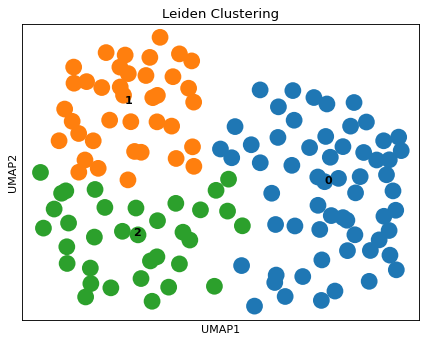

In [63]:
# Plot Leiden clustering results
sc.pl.umap(adata, color=['leiden'], legend_loc='on data', 
           title='Leiden Clustering', show=True)

## Cell Type Annotation with CellTypist

In [64]:
# Download and load model
celltypist.models.download_models(force_update=False)
model = celltypist.models.Model.load(model='Immune_All_Low.pkl')

print(f"Running CellTypist on {adata.n_obs} cells...")

# Predict cell types
predictions = celltypist.annotate(adata, model='Immune_All_Low.pkl', majority_voting=True)

# Transfer predictions to adata
adata.obs['cell_type'] = predictions.predicted_labels.majority_voting
adata.obs['cell_type_predicted'] = predictions.predicted_labels.predicted_labels

print(f"\nCell type annotation complete")
print(f"Identified cell types: {adata.obs['cell_type'].unique()}")

📂 Storing models in /home/ryan/.celltypist/data/models
⏩ Skipping [1/58]: Immune_All_Low.pkl (file exists)
⏩ Skipping [2/58]: Immune_All_High.pkl (file exists)
⏩ Skipping [3/58]: Adult_COVID19_PBMC.pkl (file exists)
⏩ Skipping [4/58]: Adult_CynomolgusMacaque_Hippocampus.pkl (file exists)
⏩ Skipping [5/58]: Adult_Human_MTG.pkl (file exists)
⏩ Skipping [6/58]: Adult_Human_PancreaticIslet.pkl (file exists)
⏩ Skipping [7/58]: Adult_Human_PrefrontalCortex.pkl (file exists)
⏩ Skipping [8/58]: Adult_Human_Skin.pkl (file exists)
⏩ Skipping [9/58]: Adult_Human_Vascular.pkl (file exists)
⏩ Skipping [10/58]: Adult_Mouse_Gut.pkl (file exists)
⏩ Skipping [11/58]: Adult_Mouse_OlfactoryBulb.pkl (file exists)
⏩ Skipping [12/58]: Adult_Pig_Hippocampus.pkl (file exists)
⏩ Skipping [13/58]: Adult_RhesusMacaque_Hippocampus.pkl (file exists)
⏩ Skipping [14/58]: Adult_cHSPCs_Illumina.pkl (file exists)
⏩ Skipping [15/58]: Adult_cHSPCs_Ultima.pkl (file exists)
⏩ Skipping [16/58]: Autopsy_COVID19_Lung.pkl (fil

Running CellTypist on 132 cells...

Cell type annotation complete
Identified cell types: ['Epithelial cells', 'Fibroblasts', 'Double-positive thymocytes', 'Tcm/Naive helper T cells']
Categories (4, object): ['Double-positive thymocytes', 'Epithelial cells', 'Fibroblasts', 'Tcm/Naive helper T cells']


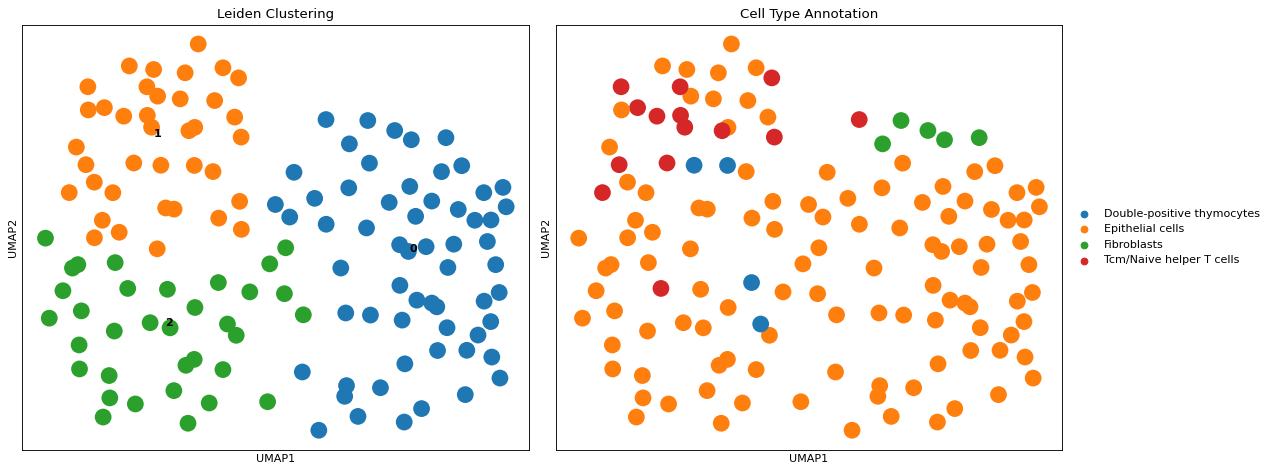

In [52]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sc.pl.umap(adata, color=['leiden'], legend_loc='on data', 
           title='Leiden Clustering', ax=ax1, show=False)

sc.pl.umap(adata, color=['cell_type'], 
           title='Cell Type Annotation', ax=ax2, show=False)

plt.tight_layout()
plt.show()

## Analysis Summary

In [65]:
import pandas as pd

print("SINGLE-CELL RNA-SEQ ANALYSIS SUMMARY".center(70))

# Dataset overview
print("\n[DATASET OVERVIEW]")
print(f"  Total cells:              {adata.n_obs:>8,}")
print(f"  Total genes:              {adata.n_vars:>8,}")
print(f"  Total UMI counts:         {int(adata.raw.X.sum()):>8,}")
print(f"  Median UMIs per cell:     {int(np.median(adata.obs['total_counts'])):>8,}")
print(f"  Median genes per cell:    {int(np.median(adata.obs['n_genes_by_counts'])):>8,}")

# Clustering results
print("\n[CLUSTERING RESULTS]")
print(f"  Leiden clusters:          {len(adata.obs['leiden'].unique()):>8}")
print(f"  Resolution:               {0.5:>8.1f}")
leiden_counts = adata.obs['leiden'].value_counts().sort_index()
print("\n  Cluster distribution:")
for cluster, count in leiden_counts.items():
    pct = 100 * count / len(adata)
    print(f"    Cluster {cluster}:  {count:>5} cells ({pct:>5.1f}%)")

# Cell type annotation
print("\n[CELL TYPE ANNOTATION]")
print(f"  Unique cell types:        {len(adata.obs['cell_type'].unique()):>8}")
print(f"  Model used:               Immune_All_Low.pkl")
print("\n  Cell type distribution:")
cell_type_counts = adata.obs['cell_type'].value_counts()
for cell_type, count in cell_type_counts.items():
    pct = 100 * count / len(adata)
    print(f"    {cell_type:<25} {count:>5} cells ({pct:>5.1f}%)")

# Quality metrics
print("\n[QUALITY METRICS]")
print(f"  Mean UMIs per cell:       {adata.obs['total_counts'].mean():>8,.0f}")
print(f"  Std UMIs per cell:        {adata.obs['total_counts'].std():>8,.0f}")
print(f"  Mean genes per cell:      {adata.obs['n_genes_by_counts'].mean():>8,.1f}")
print(f"  Std genes per cell:       {adata.obs['n_genes_by_counts'].std():>8,.1f}")

                 SINGLE-CELL RNA-SEQ ANALYSIS SUMMARY                 

[DATASET OVERVIEW]
  Total cells:                   132
  Total genes:                    19
  Total UMI counts:            9,685
  Median UMIs per cell:           29
  Median genes per cell:          12

[CLUSTERING RESULTS]
  Leiden clusters:                 3
  Resolution:                    0.5

  Cluster distribution:
    Cluster 0:     60 cells ( 45.5%)
    Cluster 1:     38 cells ( 28.8%)
    Cluster 2:     34 cells ( 25.8%)

[CELL TYPE ANNOTATION]
  Unique cell types:               4
  Model used:               Immune_All_Low.pkl

  Cell type distribution:
    Epithelial cells            109 cells ( 82.6%)
    Tcm/Naive helper T cells     14 cells ( 10.6%)
    Fibroblasts                   5 cells (  3.8%)
    Double-positive thymocytes     4 cells (  3.0%)

[QUALITY METRICS]
  Mean UMIs per cell:             40
  Std UMIs per cell:              33
  Mean genes per cell:          11.4
  Std genes per cell: 